# Initalization

In [30]:
import scipy.io
import cmath
import numpy as np
import time
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler
from math import sqrt
import cmath

%matplotlib inline

# output precision
np.set_printoptions(precision=3)

In [31]:
%pwd

'D:\\dev\\FH\\notebooks'

In [32]:
sys.path.append(r'..\\src\\')
import dsa

In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
colors1 = [sns.xkcd_rgb["pale red"], sns.xkcd_rgb["medium green"], sns.xkcd_rgb["denim blue"]]
colors2 = ['r', 'g', 'b']
colors3 = ['k', 'k', 'k']
#plt.rc('axes', prop_cycle=(cycler('color', colors)))

## Functions

In [35]:
def get_V_ph_v(V, phi_v):
    """Return rect coordinates from magnitude and angle.
    """
    res = None
    # check if V is of type complex
    if np.iscomplex(V.any()):
        for v, phi in zip(V, phi_v):
            if (res is None):
                res = np.matrix([cmath.rect(v.real[0, 0], phi[0, 0])])
            else:
                res = np.vstack((res, cmath.rect(v.real[0, 0], phi[0, 0])))
    # handle as real value
    else:
        for v, phi in zip(V, phi_v):
            if (res is None):
                res = np.matrix([cmath.rect(v, phi)])
            else:
                res = np.vstack((res, cmath.rect(v, phi)))
    return np.matrix(res)

In [36]:
def print_amp_ph(v,label='',pu=False,V_nom=10000):
    angles = ' angles:' + str(np.angle(v.T,deg=1))
    if pu:
        print(label + ' magnitude: ' + str(abs(v.T)/V_nom) + angles)
    else:
        print(label + ' magnitude: ' + str(abs(v.T)) + angles)

In [37]:
def plot_vector(V,title='unknown', colors = ['r','g','b']):
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection='polar')
    ax.margins(0)
    i = 0
    for v in V:
        label = 'V_' + str(i)
        ax.plot([0,np.angle(v)],[0,np.absolute(v)],marker='o',label=label, color=colors[i])
        i += 1
    ax.legend()
    plt.suptitle(title, size=12, verticalalignment='bottom')
    plt.show()
    
def plot_vectors(V,title='unknown'):
    colors = ['r','g','b']
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection='polar')
    ax.margins(0)
    for j in range(V.shape[0]//3):
        i = 0
        for v in V[3*j:3*j+3]:
            label = 'V_' + str(i)
            ax.plot([0,np.angle(v)],[0,np.absolute(v)],marker='o',label=label, color=colors[i])
            i += 1
    ax.legend()
    plt.suptitle(title, size=12, verticalalignment='bottom')
    plt.show()
    return fig

def plot_subplot_vectors(list_V,title=[],figsize=(), colors = ['r','g','b']): 
    if len(figsize) == 0:
        figsize=(7*len(list_V),7)

    f, axarr = plt.subplots(ncols = len(list_V), subplot_kw=dict(projection='polar'),figsize=figsize)
    # ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection='polar')
    j = 0
    for V,ax in zip(list_V, axarr):
        i = 0
        for v in V:
            if len(title) != 0:
                label = title[j] + ' ' + str(i)
            else:
                label = str(i)
            ax.margins(0)
            ax.plot([0,np.angle(v)],[0,np.absolute(v)],marker='o',label=label, color=colors[i])
            i += 1
            ax.legend()
            ax.set_title(title[j])
        j +=1

# Symmetrical Components

## Transformation matrix

In [38]:
a = cmath.exp((120 * cmath.pi / 180) * 1j)
print('{0:.3f}'.format(a))
print('{0:.3f}'.format(a**2))

-0.500+0.866j
-0.500-0.866j


 magnitude: [[1. 1. 1.]] angles:[[   0. -120.  120.]]


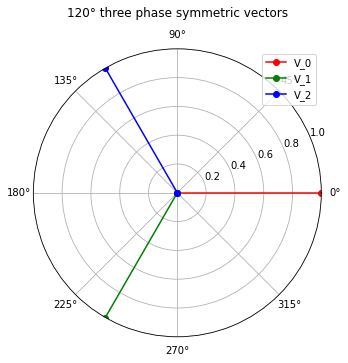

In [39]:
Va = np.vstack((1,a**2,a))
print_amp_ph(Va)
plot_vector(Va, title='120° three phase symmetric vectors')

Definition of $T$ as p,n,0 Transformation

In [40]:
a = cmath.exp((120 * cmath.pi / 180) * 1j)

T = np.matrix([[1 + 0j, 1 + 0j, 1 + 0j],
               [1 + 0j, a ** 2, a],
               [1 + 0j, a, a ** 2]])

In [41]:
T.I*1/3

matrix([[ 0.111-4.112e-17j,  0.111+3.701e-17j,  0.111+1.850e-17j],
        [ 0.111+2.467e-17j, -0.056+9.623e-02j, -0.056-9.623e-02j],
        [ 0.111+1.645e-17j, -0.056-9.623e-02j, -0.056+9.623e-02j]])

## Zero, positive and negative components

In [42]:
#V = dsa.tf.init_V()
V = Va

In [43]:
Vu = get_V_ph_v(np.array([1.05, 1, 0.95]), np.array([np.radians(4), np.radians(-124), np.radians(+126)]))

In [44]:
Vs = T.I*Vu

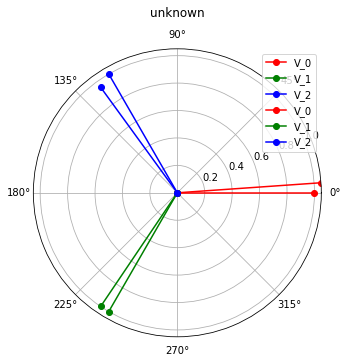

In [45]:
plot_vectors(np.vstack((V,Vu)));

In [46]:
v0 = 1/3*(Vu[0] + Vu[1] + Vu[2])
v1 = 1/3*(Vu[0] + a*Vu[1] + a**2 * Vu[2])
v2 = 1/3*(Vu[0] + a**2*Vu[1] + a * Vu[2])

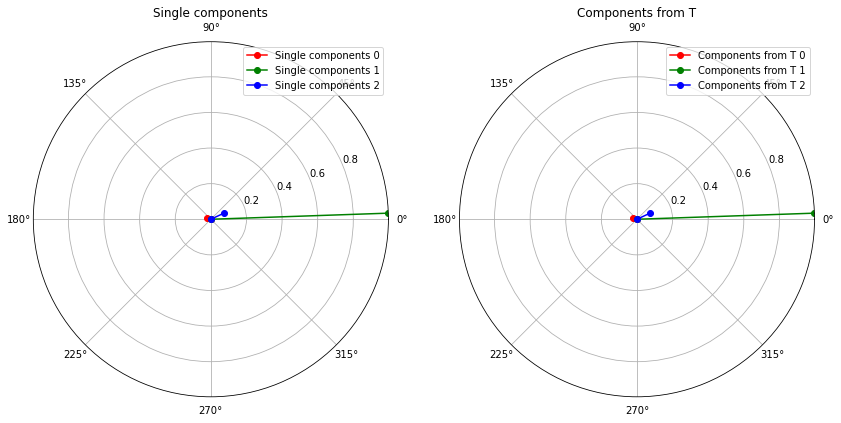

In [47]:
plot_subplot_vectors([np.vstack((v0,v1,v2)), Vs], ['Single components', 'Components from T'])

In [48]:
V0 = np.vstack((v0,v0,v0))
V1 = np.vstack((v1, dsa.tf.rotate_V(v1,-2*np.pi/3), dsa.tf.rotate_V(v1, 2*np.pi/3)))
V2 = np.vstack((v2, dsa.tf.rotate_V(v2, 2*np.pi/3), dsa.tf.rotate_V(v2,-2*np.pi/3)))

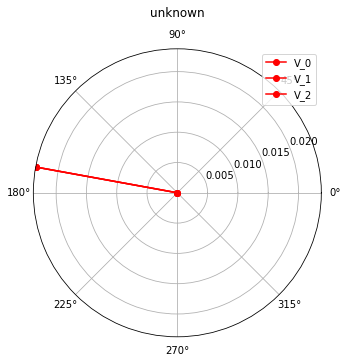

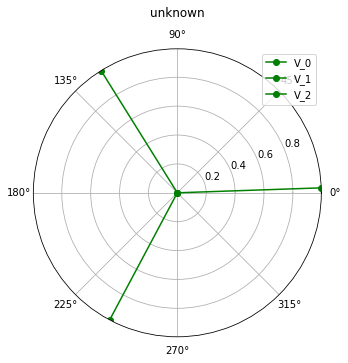

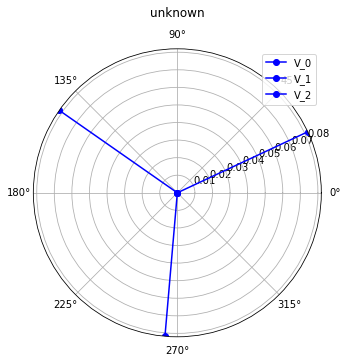

In [49]:
plot_vector(V0, colors=['r', 'r', 'r']);
plot_vector(V1, colors=['g', 'g', 'g']);
plot_vector(V2, colors=['b', 'b', 'b']);

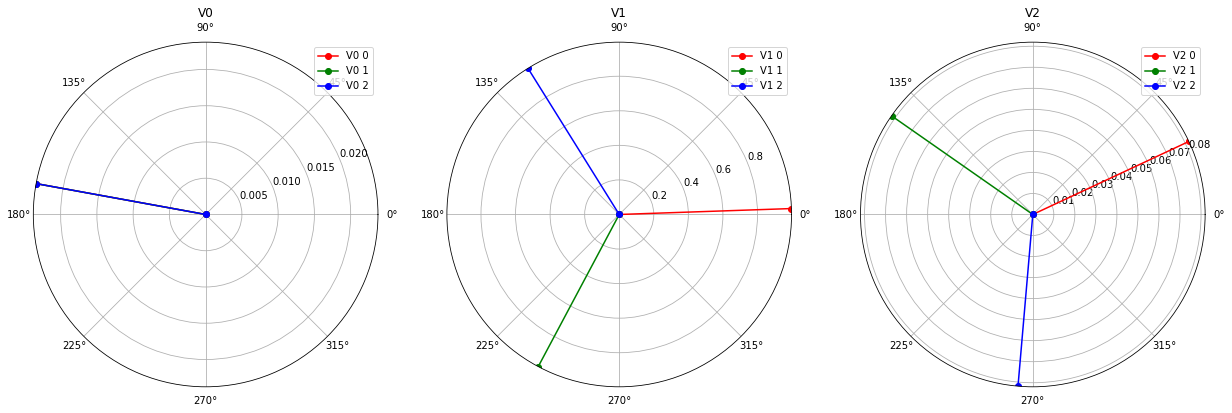

In [50]:
plot_subplot_vectors([V0,V1,V2], ['V0', 'V1', 'V2'], colors=colors2)

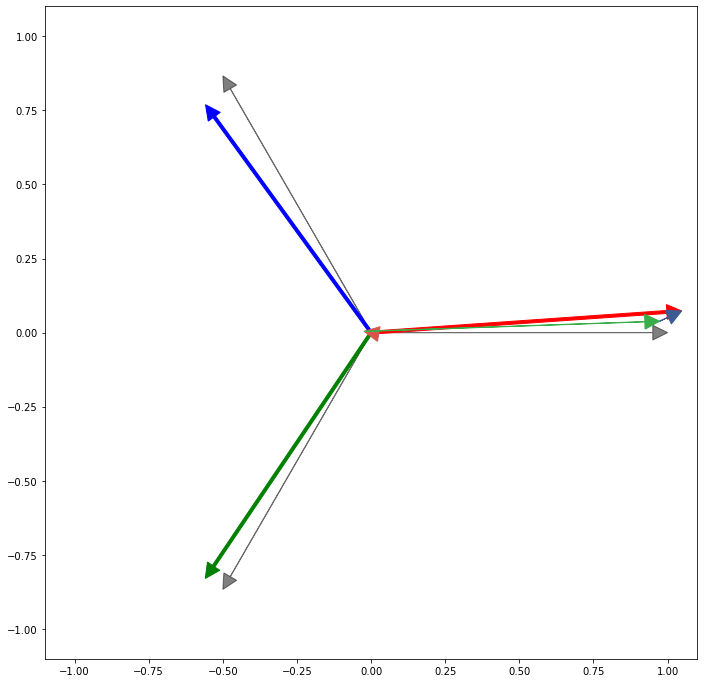

In [51]:
fig = plt.figure(figsize=(12,12))
ax = plt.gca()
ax.set_xlim([-np.abs(V).max()*1.1, np.abs(V).max()*1.1])
ax.set_ylim([-np.abs(V).max()*1.1, np.abs(V).max()*1.1])
ax.set_aspect('equal', adjustable='box')
for i in range(V.shape[0]):
    ax.arrow(0, 0, V[i,0].real, V[i,0].imag, alpha=0.5, head_width=0.05, head_length=0.05, length_includes_head=True, color=colors3[i])

for i in range(Vu.shape[0]):
    ax.arrow(0, 0, Vu[i,0].real, Vu[i,0].imag, head_width=0.05, head_length=0.05, width=0.01, length_includes_head=True, color=colors2[i])
    
r_old = 0
i_old = 0
for i in range(Vs.shape[0]):
    ax.arrow(r_old, i_old, Vs[i,0].real, Vs[i,0].imag, head_width=0.05, head_length=0.05, length_includes_head=True, color=colors1[i])
    r_old = r_old + Vs[i,0].real
    i_old = i_old + Vs[i,0].imag

In [52]:
v0

matrix([[-0.023+0.004j]])

# Symmetrical Component transformation of Impedance

Definition of according to power factory line impedance parameters

In [53]:
# line impedance (PowerFactory DSSE_lateral)
Z_abcN = np.matrix([[ 2.50+2.j ,  1.25+0.8j,  1.25+0.8j, 0],
                    [ 1.25+0.8j,  2.50+2.j ,  1.25+0.8j, 0],
                    [ 1.25+0.8j,  1.25+0.8j,  2.50+2.j,  0],
                    [ 0,          0,          0,         1.25+1.2j]])
print(Z_abcN)

[[2.5 +2.j  1.25+0.8j 1.25+0.8j 0.  +0.j ]
 [1.25+0.8j 2.5 +2.j  1.25+0.8j 0.  +0.j ]
 [1.25+0.8j 1.25+0.8j 2.5 +2.j  0.  +0.j ]
 [0.  +0.j  0.  +0.j  0.  +0.j  1.25+1.2j]]


In [54]:
Z_abcN.shape

(4, 4)

Power Factory defintion of symmetrical impedance matrix

In [55]:
# line impedance (PowerFactory DSSE_lateral)
Z_012 = np.matrix('5+3.6j    0          0; \
                 0         1.25+1.2j  0; \
                 0         0          1.25+1.2j', dtype='complex')

Transform $Z_{012}$ to $Z_{abc}$ 

In [56]:
Z_abc = A * Z_012 * A.I
print(Z_abc)
Z_012test = A.I * Z_abc * A
print(Z_012test)

NameError: name 'A' is not defined

In [57]:
Z0 = 5+3.6j
Z1= 1.25 + 1.2j
Z2 = Z1
(Z0+2*Z1)/3

(2.5+2j)

# Kron reduction

In [58]:
# kron reduction (e.g. 4x4 to 3x3 reducing neutral phase)
def kron_red(A,n):
    A_red = A.copy()
    for row in range(0,A.shape[0]):
        for col in range (0,A.shape[1]):
            if row==n or col==n:
                A_red[row,col] = 0
            else:
                A_red[row,col] = A[row,col] - A[row,n]*A[n,col]/A[n,n]
    # remove n th column
    A_red = np.delete(A_red, (n), axis=0)
    A_red = np.delete(A_red, (n), axis=1)
    return A_red

In [59]:
Z_abc_red = kron_red(Z_abcN,3)
print(Z_abc_red)

[[2.5 +2.j  1.25+0.8j 1.25+0.8j]
 [1.25+0.8j 2.5 +2.j  1.25+0.8j]
 [1.25+0.8j 1.25+0.8j 2.5 +2.j ]]


Kron reduction test case:
http://uetianblogger.blogspot.co.at/2015/12/kron-reduction-using-matlab-code.html

In [60]:
M_test = np.matrix([[ -16.75j, 11.75j, 2.50j, 2.50j],
                    [ 11.75j, -19.25j, 2.50j, 5.0j],
                    [ 2.50j, 2.50j, -5.80j,  0],
                    [ 2.50j, 5.00j, 0.0, -8.30j]])
M = kron_red(M_test,1)
print('full:')
print(M_test)
print('reduced:')
print(M)

full:
[[-0.-16.75j  0.+11.75j  0. +2.5j   0. +2.5j ]
 [ 0.+11.75j -0.-19.25j  0. +2.5j   0. +5.j  ]
 [ 0. +2.5j   0. +2.5j  -0. -5.8j   0. +0.j  ]
 [ 0. +2.5j   0. +5.j    0. +0.j   -0. -8.3j ]]
reduced:
[[0.-9.578j 0.+4.026j 0.+5.552j]
 [0.+4.026j 0.-5.475j 0.+0.649j]
 [0.+5.552j 0.+0.649j 0.-7.001j]]


## Impedance symmetrical components transformation

In [61]:
# simple test matrix (real)
Z = np.matrix('5 1 1; \
               1 5 1; \
               1 1 5', dtype='complex')

In [62]:
Z_s = T.I * Z * T

In [63]:
Z_s

matrix([[ 7.000e+00+3.022e-16j, -1.778e-16+2.269e-16j,
         -7.474e-16-2.145e-16j],
        [ 4.441e-16-2.220e-16j,  4.000e+00+1.824e-16j,
         -2.220e-16+3.899e-16j],
        [ 2.220e-16+0.000e+00j,  4.441e-16-4.427e-17j,
          4.000e+00+1.381e-16j]])

In [64]:
Z_u = T * Z_s * T.I
Z_u

matrix([[5.-1.172e-16j, 1.+3.577e-16j, 1.+1.357e-16j],
        [1.-1.983e-17j, 5.+7.745e-16j, 1.-1.996e-16j],
        [1.-1.164e-15j, 1.+1.505e-15j, 5.+9.919e-16j]])

In [65]:
# S = U * I

In [66]:
# U = Z * I
I = np.matrix('1.25+1.2j 0          0; \
                 0         1.25+1.2j  0; \
                 0         0          5+3.6j', dtype='complex')